In [1]:
!pip install -q gdown ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.2 MB/s eta 0:00:00


In [2]:
import gdown
from pathlib import Path
import zipfile
import yaml
from ultralytics import YOLO
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import shutil

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Введение

В данной работе решается задача детекции патологий на рентгеновских снимках грудной клетки в рамках датасета VinBigData Chest X-ray Abnormalities Detection.

Особенностью датасета является наличие множественных аннотаций от разных радиологов для одного изображения. Для повышения качества обучающих данных использовалась согласованная разметка, полученная путем объединения bounding box’ов с использованием IoU и выбора итогового класса на основе голосования.

В качестве модели детекции использовалась архитектура YOLO (Ultralytics YOLO11). Были проведены эксперименты с различными конфигурациями модели.

DICOM-изображения были предварительно преобразованы в PNG и сжаты с сохранением пропорций (1024 пикселя по длинной стороне). На основе согласованной разметки были сформированы label-файлы в формате YOLO.

# Подготовка данных для YOLO

In [4]:
!mkdir -p /content/yolo_data

!cp "/content/drive/MyDrive/Проект ВШЭ 9/DL/images.zip" /content/yolo_data/
!cp "/content/drive/MyDrive/Проект ВШЭ 9/DL/labels.zip" /content/yolo_data/

!unzip -q /content/yolo_data/images.zip -d /content/yolo_data/
!unzip -q /content/yolo_data/labels.zip -d /content/yolo_data/

In [5]:
root = Path("/content/yolo_data")

In [6]:
label_root = root / "labels"

class_ids = set()
label_files = list(label_root.rglob("*.txt"))

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cls_id = int(line.split()[0])
            class_ids.add(cls_id)

print("Class ids found:", sorted(class_ids))
print("Number of classes:", len(class_ids))
print("Number of label files:", len(label_files))

Class ids found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Number of classes: 14
Number of label files: 15000


In [7]:
data = {
    "path": str(root),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": sorted(class_ids)
}

with open(root / "data.yaml", "w", encoding="utf-8") as f:
    yaml.dump(data, f, sort_keys=False, allow_unicode=True)

print((root / "data.yaml").read_text(encoding="utf-8"))

path: /content/yolo_data
train: images/train
val: images/val
test: images/test
names:
- 0
- 1
- 2
- 3
- 4
- 5
- 6
- 7
- 8
- 9
- 10
- 11
- 12
- 13



# Эксперимент 1

Эксперимент 1: модель: yolo11n, imgsz=640, много background images

In [ ]:
model = YOLO("yolo11n.pt")

results = model.train(
    data=str(root / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=32,
    workers=2,
    device=0,
    project="/content/drive/MyDrive/yolo_runs",
    name="yolo11n_xray",
    patience=20,
    save_period=1,
    plots=True
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_xray, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspecti

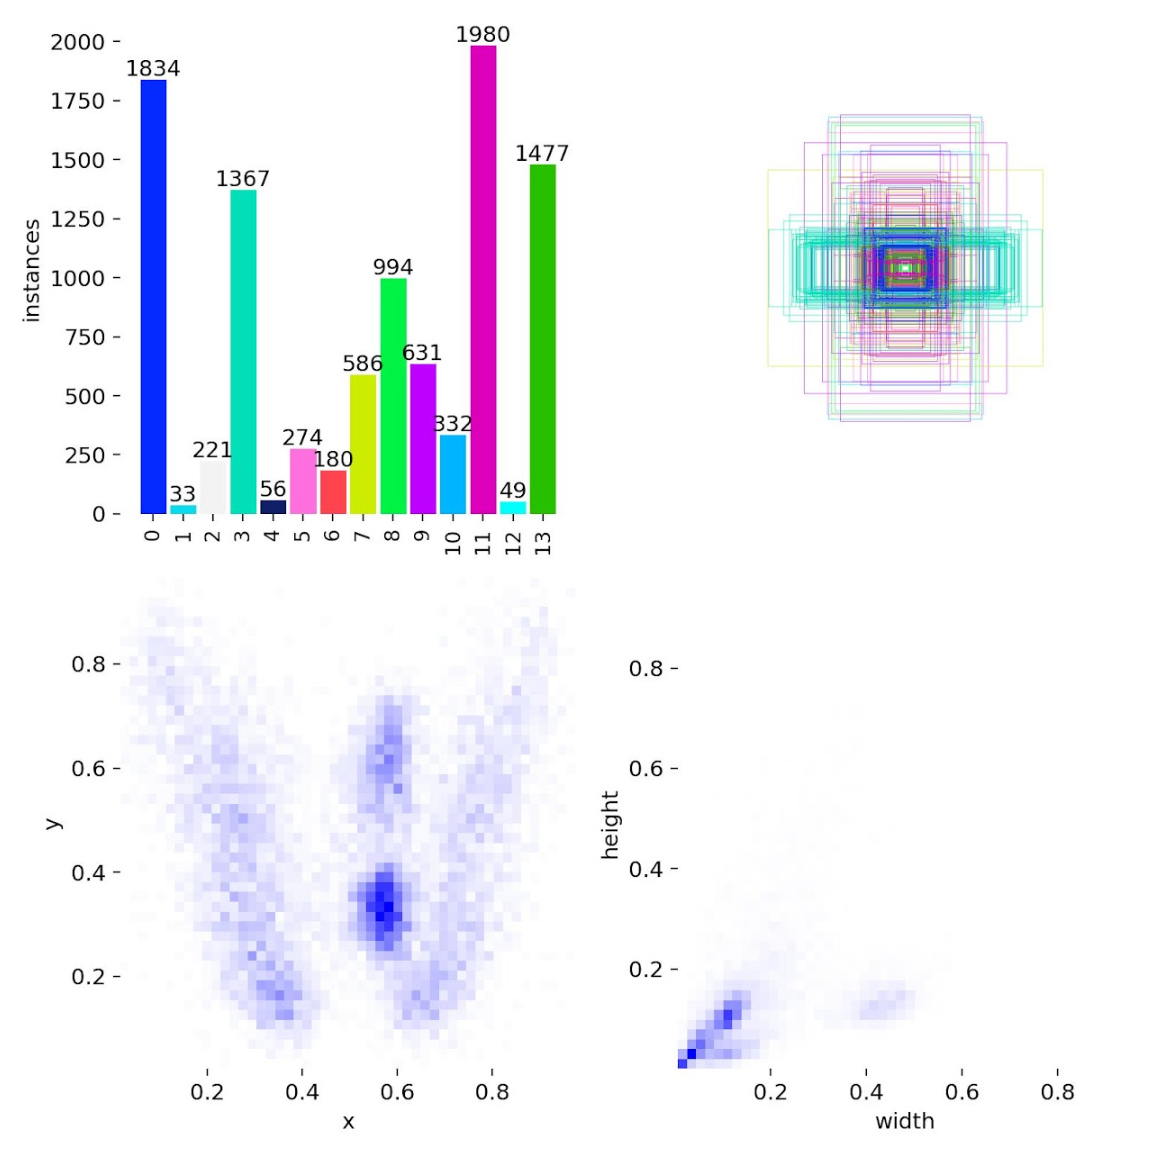

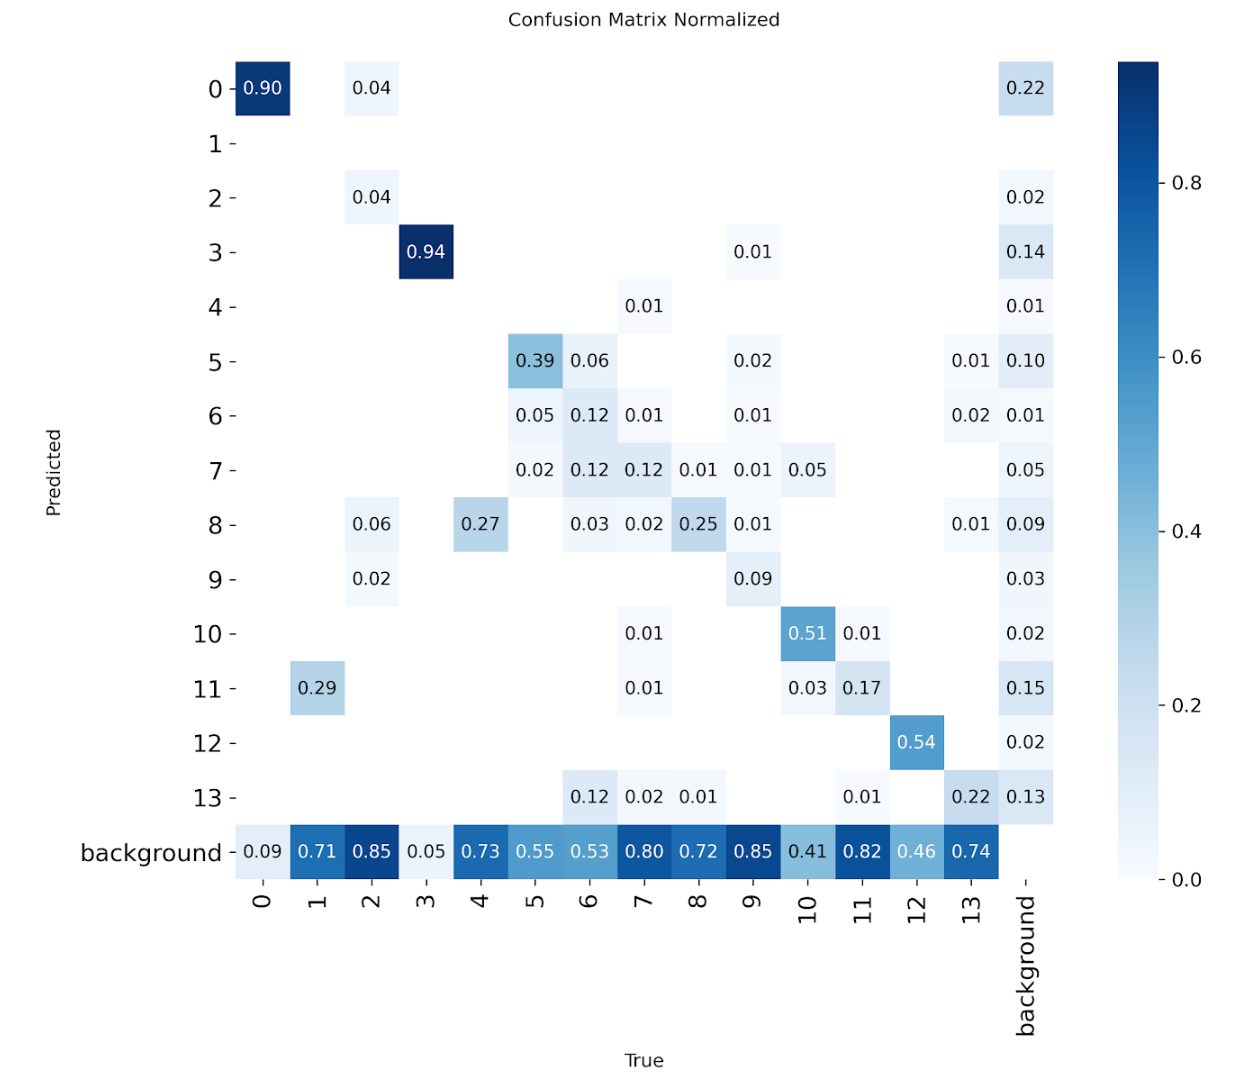

Присутствует сильный дисбаланс классов, много background images, из-за чего модель часто предсказывает background вместо других классов. Хотя иногда путаются 1 и 11 (Atelectasis и Pleural thickening), 4 и 8 классы (Consolidation и Nodule/Mass). Но основная проблема в низком recall: модель не видит патологии.

Попробуем удалить часть background images из тренировочной выборки так, чтобы их стало 50%, а не 70.

In [ ]:
random.seed(42)

root = Path("/content/yolo_data")
images_dir = root / "images" / "train"
labels_dir = root / "labels" / "train"

removed_images_dir = root / "removed_background" / "images"
removed_labels_dir = root / "removed_background" / "labels"

removed_images_dir.mkdir(parents=True, exist_ok=True)
removed_labels_dir.mkdir(parents=True, exist_ok=True)

keep_ratio = 0.1

target_bg_count = None

all_images = sorted(images_dir.glob("*.png"))

bg_images = []
obj_images = []

for img_path in all_images:
    label_path = labels_dir / f"{img_path.stem}.txt"

    if not label_path.exists():
        bg_images.append(img_path)
    else:
        text = label_path.read_text(encoding="utf-8").strip()
        if text == "":
            bg_images.append(img_path)
        else:
            obj_images.append(img_path)

print(f"Всего train images: {len(all_images)}")
print(f"Object images: {len(obj_images)}")
print(f"Background images: {len(bg_images)}")

if target_bg_count is None:
    keep_bg_count = int(len(bg_images) * keep_ratio)
else:
    keep_bg_count = min(target_bg_count, len(bg_images))

remove_bg_count = len(bg_images) - keep_bg_count

print(f"\nОставим background: {keep_bg_count}")
print(f"Уберем background: {remove_bg_count}")

bg_to_keep = set(random.sample(bg_images, keep_bg_count))
bg_to_remove = [p for p in bg_images if p not in bg_to_keep]

for img_path in bg_to_remove:
    label_path = labels_dir / f"{img_path.stem}.txt"

    shutil.move(str(img_path), str(removed_images_dir / img_path.name))

    if label_path.exists():
        shutil.move(str(label_path), str(removed_labels_dir / label_path.name))

print(f"Перемещено background images: {len(bg_to_remove)}")
print(f"Осталось train images: {len(list(images_dir.glob('*.png')))}")

Всего train images: 9000
Object images: 2629
Background images: 6371

Оставим background: 637
Уберем background: 5734
Перемещено background images: 5734
Осталось train images: 3266


# Эксперимент 2: удаление части background images

Эксперимент 2: модель: yolo11n, imgsz=1024, половина background images в train.

Попробуем увеличить размер изображения для возможного повышения точности.

In [ ]:
model = YOLO("/content/drive/MyDrive/yolo_runs /yolo11n_xray/weights/best.pt")

results = model.train(
    data="/content/yolo_data/data.yaml",
    epochs=100,
    imgsz=1024,
    batch=16,
    workers=2,
    device=0,
    project="/content/drive/MyDrive/yolo_runs",
    name="yolo11n_xray_bg50_img1024",
    optimizer="AdamW",
    lr0=1e-4,
    lrf=1e-2,
    cos_lr=True,
    patience=20,
    plots=True
)

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo_runs /yolo11n_xray/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_xray_bg50_img10242,

Результат особо не поменялся. Увеличение размера изображения и сокращение background images не повлияло.

In [ ]:
for p in [
    Path("/content/yolo_data/labels/train.cache"),
    Path("/content/yolo_data/labels/val.cache"),
]:
    if p.exists():
        p.unlink()
        print(f"Deleted: {p}")

Deleted: /content/yolo_data/labels/train.cache
Deleted: /content/yolo_data/labels/val.cache


# Эксперимент 3: более мощная модель

Эксперимент 3: модель: yolo11m, imgsz=640, половина background images в train.

In [ ]:
model = YOLO("yolo11m.pt")

results = model.train(
    data=str(root / "data.yaml"),
    epochs=100,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,
    project="/content/drive/MyDrive/yolo_runs",
    name="yolo11s_xray_640_yolo11m",
    optimizer="AdamW",
    lr0=1e-3,
    lrf=1e-2,
    cos_lr=True,
    patience=20,
    plots=True
)

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_xray_640_yolo11m, nbs=64, nms=False, opset=None, optimize=False, optimize

KeyboardInterrupt: 

За 64 эпохи результат не изменился.

# Сравнение результатов экспериментов

| № | Модель | imgsz | epochs | batch | optimizer | background | mAP50 | mAP50-95 | Precision | Recall | Комментарий |
|---|--------|------:|-------:|------:|-----------|------------|------:|----------:|----------:|--------:|-------------|
| 1 | YOLO11n | 640 | 50 | 32 | default | ~70% | 0.332 | 0.175 | 0.429 | 0.330 | лучший результат |
| 2 | YOLO11n | 1024 | 100 | 16 | AdamW | ~50% | 0.309 | 0.162 | 0.364 | 0.351 | хуже baseline |
| 3 | YOLO11m | 640 | 100 | 16 | AdamW | ~50% | ~0.31 | ~0.16 | ~0.36 | ~0.33 | без улучшения, дольше обучение |

Наилучший результат показала модель YOLO11n (imgsz=640). Более сложные конфигурации (использование изображений большего размера, YOLO11m и AdamW) не дали прироста качества. Это связано с особенностями данных: патологии слабо выражены, классы несбалансированы, а доля background велика. В таких условиях простая модель уже извлекает максимум информации, и дальнейшее усложнение архитектуры не приводит к улучшению.

# Оценка качества на тесте

Для оценки качества на тесте выбрана первая конфигурация

In [8]:
train_img = root / "images" / "train"
val_img = root / "images" / "val"
train_lbl = root / "labels" / "train"
val_lbl = root / "labels" / "val"

train_all_img = root / "images" / "train_all"
train_all_lbl = root / "labels" / "train_all"

train_all_img.mkdir(parents=True, exist_ok=True)
train_all_lbl.mkdir(parents=True, exist_ok=True)

for p in train_img.glob("*"):
    shutil.copy2(p, train_all_img / p.name)

for p in val_img.glob("*"):
    shutil.copy2(p, train_all_img / p.name)

for p in train_lbl.glob("*.txt"):
    shutil.copy2(p, train_all_lbl / p.name)

for p in val_lbl.glob("*.txt"):
    shutil.copy2(p, train_all_lbl / p.name)

print("images:", len(list(train_all_img.glob("*"))))
print("labels:", len(list(train_all_lbl.glob("*.txt"))))

images: 11250
labels: 11250


In [9]:
data = {
    "path": str(root),
    "train": "images/train_all",
    "val": "images/val",
    "test": "images/test",
    "names": sorted(class_ids)
}

with open(root / "data_train_all.yaml", "w", encoding="utf-8") as f:
    yaml.dump(data, f, sort_keys=False, allow_unicode=True)

print((root / "data_train_all.yaml").read_text(encoding="utf-8"))

path: /content/yolo_data
train: images/train_all
val: images/val
test: images/test
names:
- 0
- 1
- 2
- 3
- 4
- 5
- 6
- 7
- 8
- 9
- 10
- 11
- 12
- 13



In [10]:
model = YOLO("yolo11n.pt")

results = model.train(
    data=str(root / "data_train_all.yaml"),
    epochs=50,
    imgsz=640,
    batch=32,
    device=0,
    name="yolo11n_train_all"
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_data/data_train_all.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_train_all, nbs=64, nms=False, opset=None, optimize=False, optimi

Валидационная вборка - часть трейна, поэтому метрики в выводе не совсем честные.

In [11]:
model = YOLO("/content/runs/detect/yolo11n_train_all/weights/best.pt")

results = model.predict(
    source=str(root / "images" / "test"),
    imgsz=640,
    conf=0.05,
    iou=0.5,
    max_det=100,
    agnostic_nms=False,
    save=True,
    save_txt=True,
    name="yolo11n_xray_test_pred"
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/3750 /content/yolo_data/images/test/00053190460d56c53cc3e57321387478.png: 640x544 (no detections), 16.0ms
image 2/3750 /content/yolo_data/images/test/00176f7e1b1cb835123f95960b9a9efd.png: 640x544 (no detections), 2.8ms
image 3/3750 /content/yolo_data/images/test/0021df30f3fddef551eb3df4354b1d06.png: 640x640 1 0, 2.8ms
image 4/3750 /content/yolo_data/images/test/0032c6091dc8f1b1245fc2f5f45458fa.png: 640x608 (no detections), 17.0ms
image 5/3750 /co

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

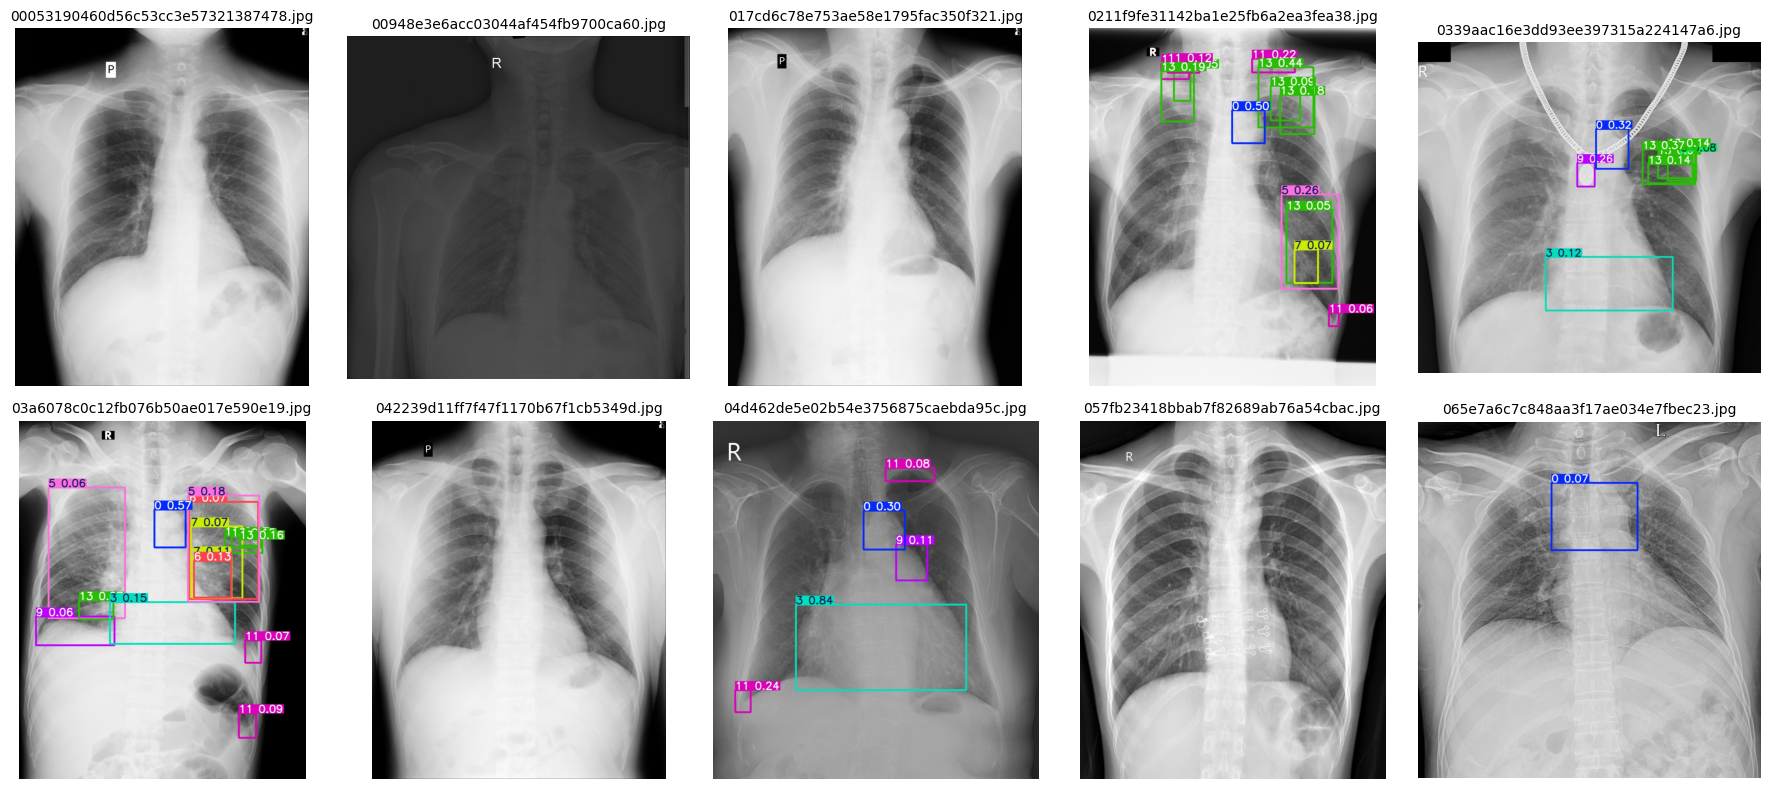

In [12]:
pred_imgs = sorted(glob.glob("/content/runs/detect/yolo11n_xray_test_pred/*.jpg"))[::10]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, img_path in zip(axes.flatten(), pred_imgs):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.split("/")[-1], fontsize=10)

for ax in axes.flatten()[len(pred_imgs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
metrics = model.val(
    data=str(root / "data_train_all.yaml"),
    split="test",
    imgsz=640,
    batch=32,
    device=0,
    plots=True
)

print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9029.2±2463.1 MB/s, size: 1018.5 KB)
val: Scanning /content/yolo_data/labels/test... 3750 images, 2652 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3750/3750 777.6it/s 4.8s
val: New cache created: /content/yolo_data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 118/118 18.9it/s 6.2s
                   all       3750       4062      0.336       0.34      0.308      0.163
                     0        794        802      0.738      0.933      0.925      0.588
                     1         13         13          0          0     0.0358     0.0146
                     2         60         78      0.129     0.0641     0.0416     0.0136
                     3        579        579      0.743      0.959      0.948      0.645
                     4   

Метрики на тесте схожи с метриками на валидационной выборке

# Итоговые выводы

Была обучена модель YOLO для детекции патологий на рентгеновских снимках грудной клетки на датасете VinBigData Chest X-ray Abnormalities Detection. Для обучения использовалась приведенная к консенсусу разметка, полученная на основе геометрического объединения аннотаций нескольких радиологов.

Было проведено несколько экспериментов с архитектурами YOLO11 и различными настройками обучения. Наилучший результат среди рассмотренных конфигураций показала модель yolo11n с размером изображения 640. Увеличение размера входного изображения до 1024, сокращение background images, а также переход к более крупной модели yolo11m не дали значимого улучшения качества.

Анализ confusion matrix показал, что основная проблема модели связана с большим количеством пропусков объектов: модель часто относит патологии к background, что приводит к низкому recall (~30%), который важен в медицинском контексте.

При этом для некоторых классов наблюдается и межклассовая путаница, однако она не является основной причиной снижения качества. В целом результаты на тестовой выборке оказались близки к результатам на валидации, что говорит об отсутствии сильного переобучения, но также подтверждает, что ключевые ограничения связаны именно с качеством и балансом данных.

В дальнейшем качество модели можно было бы улучшать за счет более тщательной работы с дисбалансом классов и более агрессивного уменьшения доли background.